# 01 · EDA — Comportamiento de Cartera y Crédito

**Proyecto:** Entidad financiera, proyecto de Riesgo de Crédito · Grupo Estoicos
**Base de datos:** 1 de 3 — Comportamiento de Cartera y Crédito (Datos Abiertos, datos.gov.co)
**Pregunta de negocio:** ¿Qué características de los solicitantes y de las solicitudes de crédito están relacionadas con el riesgo de incumplimiento?

Este notebook explora la cartera de crédito educativo por **departamento de residencia** del deudor: créditos al día, en mora (<90 y >90 días), saldos e indicador de cartera vencida.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "..")
from src.utils.loaders import load_icetex, save_processed

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

In [2]:
df = load_icetex()
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Filas: 1240 | Columnas: 11


,fecha_corte,departamento,creditos_al_dia,creditos_mora_menor_90,creditos_mora_mayor_90,total_creditos,saldo_capital,saldo_total,saldo_mora,indicador_cartera_vencida,epoca_cartera
0,2022-03-31,VAUPES,0,1,2,3,"14,629,091","16,111,879","3,268,641",100,AMORTIZACION
1,2022-03-31,VICHADA,19,12,15,46,"554,822,061","578,488,133","61,244,171",34,AMORTIZACION
2,2022-03-31,SUCRE,"3,355","1,954","1,951","7,260","75,700,773,505","78,230,689,291","5,505,018,539",32,AMORTIZACION
3,2022-03-31,GUAINIA,46,24,14,84,"1,013,145,826","1,058,404,047","62,513,259",27,AMORTIZACION
4,2022-03-31,AMAZONAS,106,54,40,200,"3,246,272,835","3,367,910,123","164,058,506",25,AMORTIZACION


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   fecha_corte                1240 non-null   datetime64[us]
 1   departamento               1240 non-null   str           
 2   creditos_al_dia            1240 non-null   float64       
 3   creditos_mora_menor_90     1240 non-null   float64       
 4   creditos_mora_mayor_90     1240 non-null   float64       
 5   total_creditos             1240 non-null   float64       
 6   saldo_capital              1240 non-null   float64       
 7   saldo_total                1240 non-null   float64       
 8   saldo_mora                 1240 non-null   float64       
 9   indicador_cartera_vencida  1240 non-null   float64       
 10  epoca_cartera              1240 non-null   str           
dtypes: datetime64[us](1), float64(8), str(2)
memory usage: 128.6 KB


## Limpieza y normalización de los datos

Arriba cargamos el DataFrame con `load_icetex()` y vimos su resultado; en esta sección explicamos **de dónde sale ese resultado**: qué problemas trae el archivo crudo, qué reglas aplica la limpieza y cómo se verifica que los datos queden sanos antes de analizarlos.

Toda la lógica de limpieza vive **centralizada** en `src/utils/loaders.py` (función `load_icetex`): la usan los notebooks, el dashboard (`app.py`) y los exportadores de agregados, de modo que todos consuman exactamente los mismos datos. Aquí no repetimos esa lógica: la **importamos y la explicamos**, comparando el crudo contra el limpio.

### 1. Contexto del dataset crudo

- **Fuente:** catálogo de Datos Abiertos del Gobierno de Colombia ([datos.gov.co](https://www.datos.gov.co)) — dataset *«Comportamiento de Cartera y Crédito»* — la **base de datos 1** de las 3 del proyecto.
- **Unidad observacional:** cada fila es un **departamento de residencia del deudor × fecha de corte** (trimestral) × **época de cartera** (`ESTUDIOS` = créditos en etapa de estudio; `AMORTIZACION` = en etapa de pago).
- **Tamaño crudo:** 1.240 filas × 11 columnas (≈ 173 KB), archivo `data/raw/Comportamiento_de_Cartera_y_Crédito._20260914.csv`.
- **Particularidad clave:** aunque contiene fechas, montos y conteos, **las 11 columnas llegan como texto**, con formatos colombianos que `pandas` no interpreta solo.

In [4]:
from src.utils.loaders import RAW

# Lectura del crudo SIN ningún parseo: así llega el archivo desde datos.gov.co
crudo = pd.read_csv(RAW / "Comportamiento_de_Cartera_y_Crédito._20260914.csv", dtype=str)
print(f"Dataset crudo: {crudo.shape[0]} filas x {crudo.shape[1]} columnas")
crudo.head(3)

Dataset crudo: 1240 filas x 11 columnas


,FECHA CORTE,DEPTORESIDENCIA,CANTIDAD CREDITOS AL DIA,CANTIDAD CREDITOS CON MORA MENOR A 90 DIAS,CANTIDAD CREDITOS MORA MAYOR A 90 DIAS,TOTAL CREDITOS,SALDO CAPITAL,SALDO TOTAL,SALDO MORA,INDICADOR CARTERA VENCIDA,EPOCA CARTERA
0,2022 Mar 31 12:00:00 AM,VAUPES,0,1,2,3,"$ 14,629,091","$ 16,111,879","$ 3,268,641",100%,AMORTIZACION
1,2022 Mar 31 12:00:00 AM,VICHADA,19,12,15,46,"$ 554,822,061","$ 578,488,133","$ 61,244,171",34.21%,AMORTIZACION
2,2022 Mar 31 12:00:00 AM,SUCRE,"3,355","1,954","1,951","7,260","$ 75,700,773,505","$ 78,230,689,291","$ 5,505,018,539",31.56%,AMORTIZACION


### 2. Problemas de calidad detectados en el crudo

Al leer el archivo **sin ningún parseo** (`dtype=str`) se evidencian los problemas típicos de un tablero publicado en datos.gov.co y exportado a CSV:

| # | Problema | Ejemplo real del crudo | Por qué molesta |
|---|----------|------------------------|-----------------|
| 1 | Montos como texto con `$` y comas de miles | `'$ 14,629,091'` | Texto no se puede sumar ni promediar |
| 2 | Fechas en formato textual mixto | `'2022 Mar 31 12:00:00 AM'` | Año + mes abreviado + día + hora 12 h; no es un formato estándar |
| 3 | Cantidades con comas de miles | `'3,355'` | Al convertir a número se leería mal |
| 4 | Indicador porcentual como texto | `'34.21%'`, `'100%'` | El `%` impide calcular con el valor |
| 5 | Columnas EN MAYÚSCULAS CON ESPACIOS | `'CANTIDAD CREDITOS CON MORA MENOR A 90 DIAS'` | Nombres imposibles de escribir sin error al programar |
| 6 | Posibles marcadores de nulo no estándar | `'-'`, `'NA'`, `'N/A'`, cadena vacía | No son `NaN` reales y contaminarían estadísticas |

> La regla de oro del proyecto: **`data/raw/` es inmutable** — los problemas se corrigen en memoria (y el resultado se guarda en `data/processed/`), nunca editando el CSV original.

In [5]:
print("Ejemplos reales del crudo (primera fila):")
print("  Fecha de corte    :", repr(crudo.loc[0, "FECHA CORTE"]))
print("  Saldo capital     :", repr(crudo.loc[0, "SALDO CAPITAL"]))
print("  Indicador vencida :", repr(crudo.loc[0, "INDICADOR CARTERA VENCIDA"]))
print("  Cantidad créditos :", repr(crudo.loc[2, "CANTIDAD CREDITOS AL DIA"]))

print("\nNombres de columnas originales:")
print(list(crudo.columns))

print("\nMarcadores de nulo '-' en el crudo :", int((crudo == "-").sum().sum()))
print("Celdas vacías o NaN en el crudo    :", int(crudo.isna().sum().sum()))
print("(en este archivo no aparece ninguno; el parser los tolera por robustez)")

Ejemplos reales del crudo (primera fila):
  Fecha de corte    : '2022 Mar 31 12:00:00 AM'
  Saldo capital     : '$ 14,629,091'
  Indicador vencida : '100%'
  Cantidad créditos : '3,355'

Nombres de columnas originales:
['FECHA CORTE', 'DEPTORESIDENCIA', 'CANTIDAD CREDITOS AL DIA', 'CANTIDAD CREDITOS CON MORA MENOR A 90 DIAS', 'CANTIDAD CREDITOS MORA MAYOR A 90 DIAS', 'TOTAL CREDITOS', 'SALDO CAPITAL', 'SALDO TOTAL', 'SALDO MORA', 'INDICADOR CARTERA VENCIDA', 'EPOCA CARTERA']

Marcadores de nulo '-' en el crudo : 0
Celdas vacías o NaN en el crudo    : 0
(en este archivo no aparece ninguno; el parser los tolera por robustez)


### 3. Reglas de limpieza aplicadas

Todas las reglas están implementadas en `load_icetex` (`src/utils/loaders.py`):

| Regla | Cómo se aplica | Ejemplo antes → después |
|-------|----------------|-------------------------|
| Parseo de montos: quitar `$` y comas de miles | `parse_monto_icetex` | `'$ 14,629,091'` → `14629091.0` |
| Parseo de cantidades: quitar comas de miles | `parse_cantidad` | `'3,355'` → `3355.0` |
| Parseo del indicador porcentual: quitar `%` y normalizar la coma decimal | `parse_porcentaje` | `'34.21%'` → `34.21` |
| Parseo de fechas con **formato explícito** (evita ambigüedad día/mes) | `pd.to_datetime(..., format='%Y %b %d %I:%M:%S %p')` | `'2022 Mar 31 12:00:00 AM'` → `Timestamp('2022-03-31')` |
| Nulos textuales → `NaN` real | `_to_float`: `'-'`, `'NA'`, `'N/A'` o vacío → `np.nan` | `'-'` → `NaN` |
| Renombrado de columnas a `snake_case` | `df.rename(columns=...)` | `'SALDO CAPITAL'` → `saldo_capital` |

**Renombrado de las 11 columnas (antes → después):**

| Columna cruda | Columna limpia |
|---------------|----------------|
| `FECHA CORTE` | `fecha_corte` |
| `DEPTORESIDENCIA` | `departamento` |
| `CANTIDAD CREDITOS AL DIA` | `creditos_al_dia` |
| `CANTIDAD CREDITOS CON MORA MENOR A 90 DIAS` | `creditos_mora_menor_90` |
| `CANTIDAD CREDITOS MORA MAYOR A 90 DIAS` | `creditos_mora_mayor_90` |
| `TOTAL CREDITOS` | `total_creditos` |
| `SALDO CAPITAL` | `saldo_capital` |
| `SALDO TOTAL` | `saldo_total` |
| `SALDO MORA` | `saldo_mora` |
| `INDICADOR CARTERA VENCIDA` | `indicador_cartera_vencida` |
| `EPOCA CARTERA` | `epoca_cartera` |

In [6]:
# Demostración de cada regla con valores reales del crudo
from src.utils.loaders import parse_monto_icetex, parse_cantidad, parse_porcentaje

pd.DataFrame({
    "valor crudo (texto)": ["$ 14,629,091", "3,355", "34.21%",
                             "2022 Mar 31 12:00:00 AM", "-"],
    "regla aplicada": ["parse_monto_icetex", "parse_cantidad", "parse_porcentaje",
                       "to_datetime(format='%Y %b %d %I:%M:%S %p')", "nulo textual → NaN"],
    "resultado": [parse_monto_icetex("$ 14,629,091"),
                  parse_cantidad("3,355"),
                  parse_porcentaje("34.21%"),
                  pd.to_datetime("2022 Mar 31 12:00:00 AM", format="%Y %b %d %I:%M:%S %p"),
                  parse_monto_icetex("-")],
})

,valor crudo (texto),regla aplicada,resultado
0,"$ 14,629,091",parse_monto_icetex,"14,629,091"
1,"3,355",parse_cantidad,"3,355"
2,34.21%,parse_porcentaje,34
3,2022 Mar 31 12:00:00 AM,to_datetime(format='%Y %b %d %I:%M:%S %p'),2022-03-31 00:00:00
4,-,nulo textual → NaN,NaN


### 4. Verificación del resultado limpio

Ninguna limpieza queda completa sin verificación. Comprobamos: dimensiones, duplicados, nulos, tipos de datos resultantes, estadísticas de columnas clave y la comparación **antes/después** de las mismas filas.

In [7]:
print("Dimensiones del DataFrame limpio :", df.shape)
print("Filas duplicadas                 :", df.duplicated().sum())
print("Valores nulos (total)            :", df.isna().sum().sum())
print("\nTipos de datos resultantes:")
df.dtypes

Dimensiones del DataFrame limpio : (1240, 11)
Filas duplicadas                 : 0
Valores nulos (total)            : 0

Tipos de datos resultantes:


fecha_corte                  datetime64[us]
departamento                            str
creditos_al_dia                     float64
creditos_mora_menor_90              float64
creditos_mora_mayor_90              float64
total_creditos                      float64
saldo_capital                       float64
saldo_total                         float64
saldo_mora                          float64
indicador_cartera_vencida           float64
epoca_cartera                           str
dtype: object

In [8]:
# Ya son numéricas: describe() funciona y tiene sentido
df[["saldo_total", "saldo_mora", "indicador_cartera_vencida"]].describe().T

,count,mean,std,min,25%,50%,75%,max
saldo_total,"1,240","168,242,299,465","274,781,817,508","6,934","13,966,740,978","65,286,348,698","211,261,476,816","1,659,226,404,046"
saldo_mora,"1,240","2,097,982,704","4,054,352,902",0,"123,368,631","727,940,307","1,978,350,775","33,712,638,606"
indicador_cartera_vencida,"1,240",15,11,0,8,12,20,100


In [9]:
# ANTES / DESPUÉS: las mismas 3 filas, columnas clave
crudo_key = crudo[["FECHA CORTE", "DEPTORESIDENCIA", "SALDO CAPITAL", "SALDO TOTAL",
                   "INDICADOR CARTERA VENCIDA"]].head(3)
limpio_key = df[["fecha_corte", "departamento", "saldo_capital", "saldo_total",
                 "indicador_cartera_vencida"]].head(3)
display(crudo_key.style.set_caption("ANTES · crudo (todo es texto)"))
display(limpio_key.style.set_caption("DESPUÉS · limpio y tipado"))

,FECHA CORTE,DEPTORESIDENCIA,SALDO CAPITAL,SALDO TOTAL,INDICADOR CARTERA VENCIDA
0,2022 Mar 31 12:00:00 AM,VAUPES,"$ 14,629,091","$ 16,111,879",100%
1,2022 Mar 31 12:00:00 AM,VICHADA,"$ 554,822,061","$ 578,488,133",34.21%
2,2022 Mar 31 12:00:00 AM,SUCRE,"$ 75,700,773,505","$ 78,230,689,291",31.56%


,fecha_corte,departamento,saldo_capital,saldo_total,indicador_cartera_vencida
0,2022-03-31 00:00:00,VAUPES,14629091.000000,16111879.000000,100.000000
1,2022-03-31 00:00:00,VICHADA,554822061.000000,578488133.000000,34.210000
2,2022-03-31 00:00:00,SUCRE,75700773505.000000,78230689291.000000,31.560000


### 5. Conclusión de la limpieza

El DataFrame quedó **listo para el análisis**: 1.240 filas × 11 columnas, **sin nulos ni duplicados**, fechas tipadas (`datetime64`), montos y conteos como `float64`, indicador en unidades porcentuales y nombres `snake_case`. Sobre esta base se construyen las secciones siguientes (serie temporal, rankings por departamento, correlaciones) y el archivo `data/processed/icetex_limpio.csv` que consume el dashboard. *(El nombre interno del archivo conserva el prefijo histórico `icetex_` por compatibilidad con `app.py`; en este notebook nos referimos al dataset por su nombre oficial: **Comportamiento de Cartera y Crédito**.)*

In [10]:
print("Rango temporal:", df["fecha_corte"].min().date(), "->", df["fecha_corte"].max().date())
print("Departamentos:", df["departamento"].nunique())
print("Épocas de cartera:", df["epoca_cartera"].unique())
print("\nEstadísticas de saldos (COP):")
df[["saldo_capital", "saldo_total", "saldo_mora"]].describe().T

Rango temporal: 2022-03-31 -> 2026-06-30
Departamentos: 46
Épocas de cartera: <ArrowStringArray>
['AMORTIZACION', 'ESTUDIOS', 'Estudios', 'Amortizacion']
Length: 4, dtype: str

Estadísticas de saldos (COP):


,count,mean,std,min,25%,50%,75%,max
saldo_capital,"1,240","148,466,792,533","240,814,213,493","6,855","12,458,740,938","60,606,863,438","183,617,162,048","1,570,054,790,151"
saldo_total,"1,240","168,242,299,465","274,781,817,508","6,934","13,966,740,978","65,286,348,698","211,261,476,816","1,659,226,404,046"
saldo_mora,"1,240","2,097,982,704","4,054,352,902",0,"123,368,631","727,940,307","1,978,350,775","33,712,638,606"


## Serie temporal: evolución de la cartera total

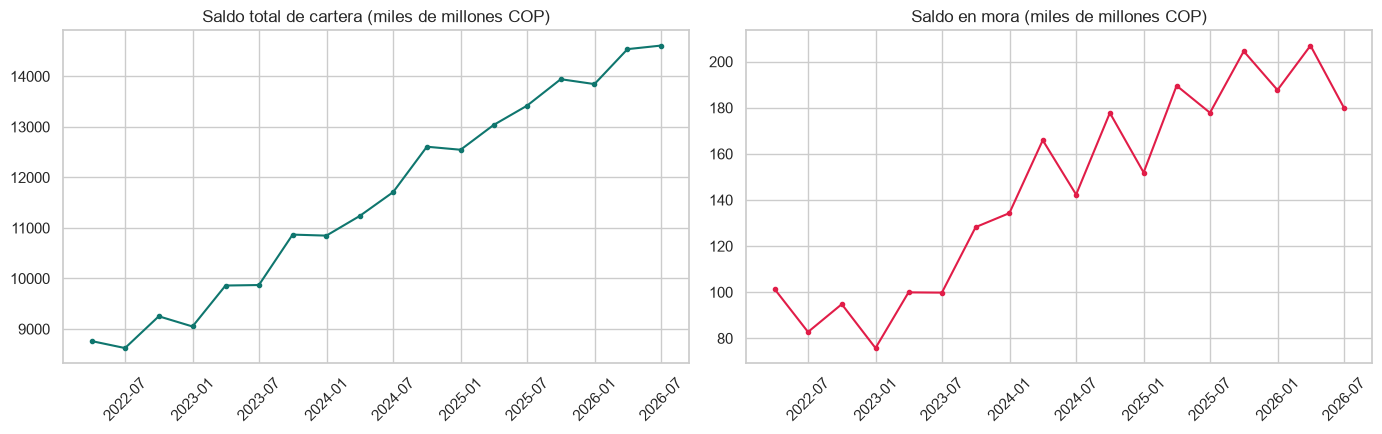

In [11]:
serie = df.groupby("fecha_corte")[["saldo_total", "saldo_mora"]].sum().reset_index()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(serie["fecha_corte"], serie["saldo_total"] / 1e9, marker="o", ms=3, color="#0f766e")
ax[0].set_title("Saldo total de cartera (miles de millones COP)")
ax[0].tick_params(axis="x", rotation=45)
ax[1].plot(serie["fecha_corte"], serie["saldo_mora"] / 1e9, marker="o", ms=3, color="#e11d48")
ax[1].set_title("Saldo en mora (miles de millones COP)")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## Indicador de cartera vencida por departamento

El **indicador de cartera vencida** mide el porcentaje de la cartera en mora. Analizamos los departamentos con mayor riesgo.

C:\Users\Admin\AppData\Local\Temp\ipykernel_18464\2690045797.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_vencida, x="indicador_cartera_vencida", y="departamento", palette="Reds_r", ax=ax)


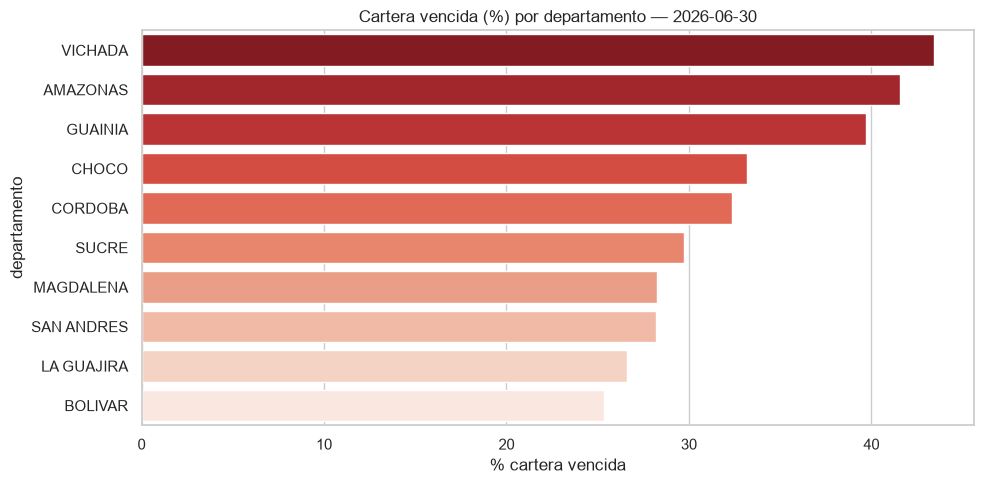

,departamento,indicador_cartera_vencida,saldo_total
1238,VICHADA,43,"895,593,526"
1172,AMAZONAS,42,"3,965,165,853"
1204,GUAINIA,40,"1,309,397,896"
1194,CHOCO,33,"8,200,256,849"
1196,CORDOBA,32,"477,654,302,960"
1230,SUCRE,30,"378,572,129,146"
1212,MAGDALENA,28,"137,151,167,243"
1226,SAN ANDRES,28,"6,062,704,647"
1210,LA GUAJIRA,27,"110,354,204,238"
1180,BOLIVAR,25,"348,830,353,823"


In [12]:
ultimo = df[df["fecha_corte"] == df["fecha_corte"].max()]
top_vencida = ultimo.nlargest(10, "indicador_cartera_vencida")[["departamento", "indicador_cartera_vencida", "saldo_total"]]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_vencida, x="indicador_cartera_vencida", y="departamento", palette="Reds_r", ax=ax)
ax.set_title(f"Cartera vencida (%) por departamento — {ultimo['fecha_corte'].max().date()}")
ax.set_xlabel("% cartera vencida")
plt.tight_layout(); plt.show()
top_vencida

## Departamentos con mayor exposición (saldo total)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18464\2545265156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_saldo, x=top_saldo["saldo_total"] / 1e9, y="departamento", palette="Blues_d", ax=ax)


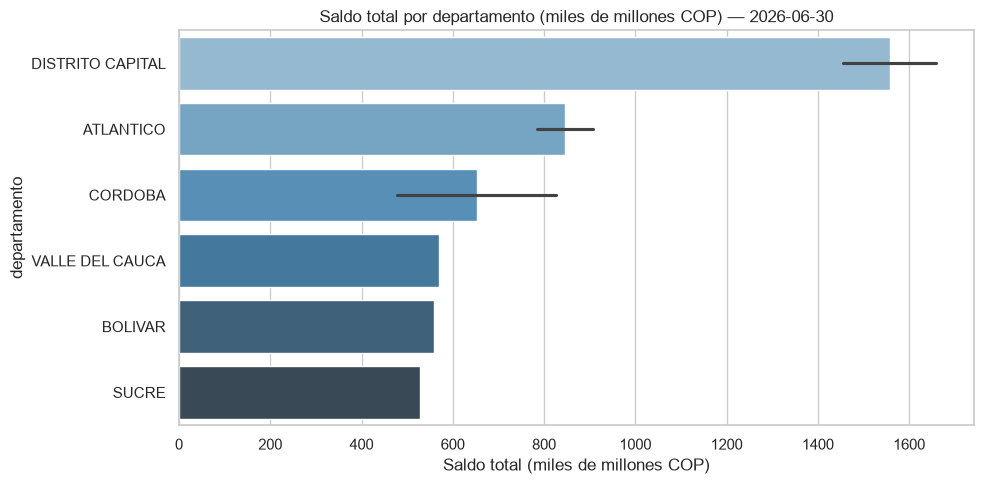

,departamento,saldo_total,indicador_cartera_vencida
1200,DISTRITO CAPITAL,"1,659,226,404,046",14
1201,DISTRITO CAPITAL,"1,455,402,818,858",7
1179,ATLANTICO,"906,882,032,568",11
1197,CORDOBA,"826,977,523,364",0
1178,ATLANTICO,"784,680,920,141",24
1234,VALLE DEL CAUCA,"570,465,537,879",16
1235,VALLE DEL CAUCA,"568,839,244,841",9
1181,BOLIVAR,"559,257,485,981",6
1231,SUCRE,"528,451,576,197",5
1196,CORDOBA,"477,654,302,960",32


In [13]:
top_saldo = ultimo.nlargest(10, "saldo_total")[["departamento", "saldo_total", "indicador_cartera_vencida"]]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_saldo, x=top_saldo["saldo_total"] / 1e9, y="departamento", palette="Blues_d", ax=ax)
ax.set_title(f"Saldo total por departamento (miles de millones COP) — {ultimo['fecha_corte'].max().date()}")
ax.set_xlabel("Saldo total (miles de millones COP)")
plt.tight_layout(); plt.show()
top_saldo

## Distribución de la mora: créditos al día vs. en mora

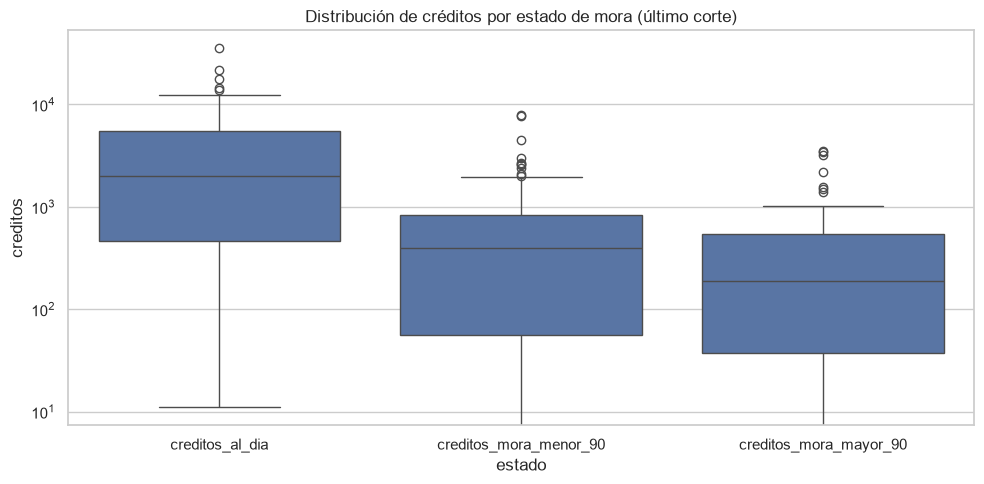

In [14]:
ultimo_mora = ultimo[["departamento", "creditos_al_dia", "creditos_mora_menor_90", "creditos_mora_mayor_90"]].melt(
    id_vars="departamento", var_name="estado", value_name="creditos")
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=ultimo_mora, x="estado", y="creditos", ax=ax)
ax.set_title("Distribución de créditos por estado de mora (último corte)")
ax.set_yscale("log")
plt.tight_layout(); plt.show()

## Correlaciones entre variables de riesgo

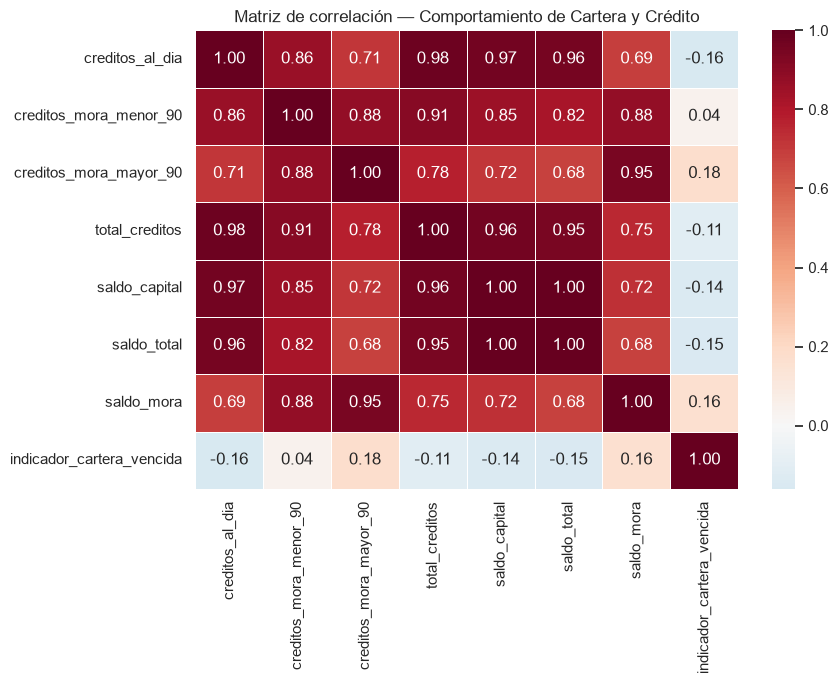

In [15]:
corr = df[["creditos_al_dia", "creditos_mora_menor_90", "creditos_mora_mayor_90",
            "total_creditos", "saldo_capital", "saldo_total", "saldo_mora",
            "indicador_cartera_vencida"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Matriz de correlación — Comportamiento de Cartera y Crédito")
plt.tight_layout(); plt.show()

## Guardar datos limpios

In [16]:
out = save_processed(df, "icetex_limpio.csv")
print("Guardado en:", out)

Guardado en: C:\Users\Admin\Documents\UNIVERSIDAD\financiera, proyecto de Riesgo de Crédito\Financiera-proyecto-de-Riesgo-de-Cr-dito\data\processed\icetex_limpio.csv


### Hallazgos preliminares
- La cartera del dataset *Comportamiento de Cartera y Crédito* se reporta por departamento de residencia del deudor, con cortes trimestrales.
- El indicador de cartera vencida varía fuertemente entre departamentos (hay departamentos con 100% de cartera vencida, aunque con saldos pequeños).
- Los departamentos con mayor saldo no necesariamente son los de mayor riesgo relativo: el riesgo depende de la composición de la mora.